In [10]:
#1. Membangun struktur direktori HDFS
!hdfs dfs -mkdir -p /user/zerouno/ecommerce/raw
!hdfs dfs -mkdir -p /user/zerouno/ecommerce/processed

!hdfs dfs -ls /user/zerouno/ecommerce/


Found 2 items
drwxr-xr-x   - zerouno supergroup          0 2026-09-08 11:42 /user/zerouno/ecommerce/processed
drwxr-xr-x   - zerouno supergroup          0 2026-09-08 11:42 /user/zerouno/ecommerce/raw


In [12]:
import numpy as np
import pandas as pd

kategori_list = ["Elektronik", "Fashion", "Makanan & Minuman", "Kesehatan & Kecantikan", "Rumah Tangga"]
metode_bayar_list = ["Transfer Bank", "E-Wallet", "COD", "Kartu Kredit"]
tanggal_range = pd.date_range("2026-08-01", "2026-08-31", freq="D")

cabang_kota = {"Magelang": 101, "Yogyakarta": 202, "Semarang": 303}

for kota, seed in cabang_kota.items():
    np.random.seed(seed)
    n = 200
    data_cabang = {
        "order_id": [f"{kota[:3].upper()}-{2000 + i}" for i in range(n)],
        "tanggal": np.random.choice(tanggal_range, size=n),
        "kategori": np.random.choice(kategori_list, size=n, p=[0.25, 0.25, 0.20, 0.15, 0.15]),
        "unit_terjual": np.random.randint(1, 8, size=n),
        "harga_satuan": np.random.choice([25000, 50000, 75000, 100000, 150000, 250000], size=n),
        "metode_pembayaran": np.random.choice(metode_bayar_list, size=n),
    }
    df_cabang = pd.DataFrame(data_cabang)
    df_cabang["kota"] = kota
    nama_file = f"transaksi_{kota.lower()}.csv"
    df_cabang.to_csv(nama_file, index=False)
    print(f"Berkas '{nama_file}' berhasil dibuat: {df_cabang.shape[0]} baris")

print("\nKetiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.")

Berkas 'transaksi_magelang.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_yogyakarta.csv' berhasil dibuat: 200 baris
Berkas 'transaksi_semarang.csv' berhasil dibuat: 200 baris

Ketiga berkas CSV cabang siap digunakan untuk Tugas Mandiri.


In [13]:
#2. Mengunggah data mentah ke HDFS
!hdfs dfs -put transaksi_magelang.csv /user/zerouno/ecommerce/raw/
!hdfs dfs -put transaksi_yogyakarta.csv /user/zerouno/ecommerce/raw/
!hdfs dfs -put transaksi_semarang.csv /user/zerouno/ecommerce/raw/

!hdfs dfs -ls -h /user/zerouno/ecommerce/raw/

Found 3 items
-rw-r--r--   1 zerouno supergroup     12.0 K 2026-09-08 11:56 /user/zerouno/ecommerce/raw/transaksi_magelang.csv
-rw-r--r--   1 zerouno supergroup     11.9 K 2026-09-08 11:56 /user/zerouno/ecommerce/raw/transaksi_semarang.csv
-rw-r--r--   1 zerouno supergroup     12.4 K 2026-09-08 11:56 /user/zerouno/ecommerce/raw/transaksi_yogyakarta.csv


In [15]:
#3. Membaca kembali dan menggabungkan data dari HDFS
import io
import subprocess
import pandas as pd

files = ["transaksi_magelang.csv", "transaksi_yogyakarta.csv", "transaksi_semarang.csv"]
dfs = []

for f in files:
    hdfs_path = f"/user/zerouno/ecommerce/raw/{f}"
    content = subprocess.check_output(["hdfs", "dfs", "-cat", hdfs_path])
    df_temp = pd.read_csv(io.BytesIO(content))
    dfs.append(df_temp)

df_gabungan = pd.concat(dfs, ignore_index=True)
print(df_gabungan["kota"].value_counts())

kota
Magelang      200
Yogyakarta    200
Semarang      200
Name: count, dtype: int64


In [16]:
#4. Mengolah dan download data ke direktori processed
df_gabungan["total_pendapatan"] = df_gabungan["unit_terjual"] * df_gabungan["harga_satuan"]

df_ringkasan = df_gabungan.groupby(["kota", "kategori"])["total_pendapatan"].sum().reset_index()

df_gabungan.to_csv("data_gabungan_bersih.csv", index=False)
df_ringkasan.to_csv("ringkasan_kota_kategori.csv", index=False)

In [17]:
!hdfs dfs -put data_gabungan_bersih.csv /user/zerouno/ecommerce/processed/
!hdfs dfs -put ringkasan_kota_kategori.csv /user/zerouno/ecommerce/processed/

!hdfs dfs -ls -h /user/zerouno/ecommerce/processed/

Found 2 items
-rw-r--r--   1 zerouno supergroup     40.3 K 2026-09-08 11:59 /user/zerouno/ecommerce/processed/data_gabungan_bersih.csv
-rw-r--r--   1 zerouno supergroup        530 2026-09-08 11:59 /user/zerouno/ecommerce/processed/ringkasan_kota_kategori.csv


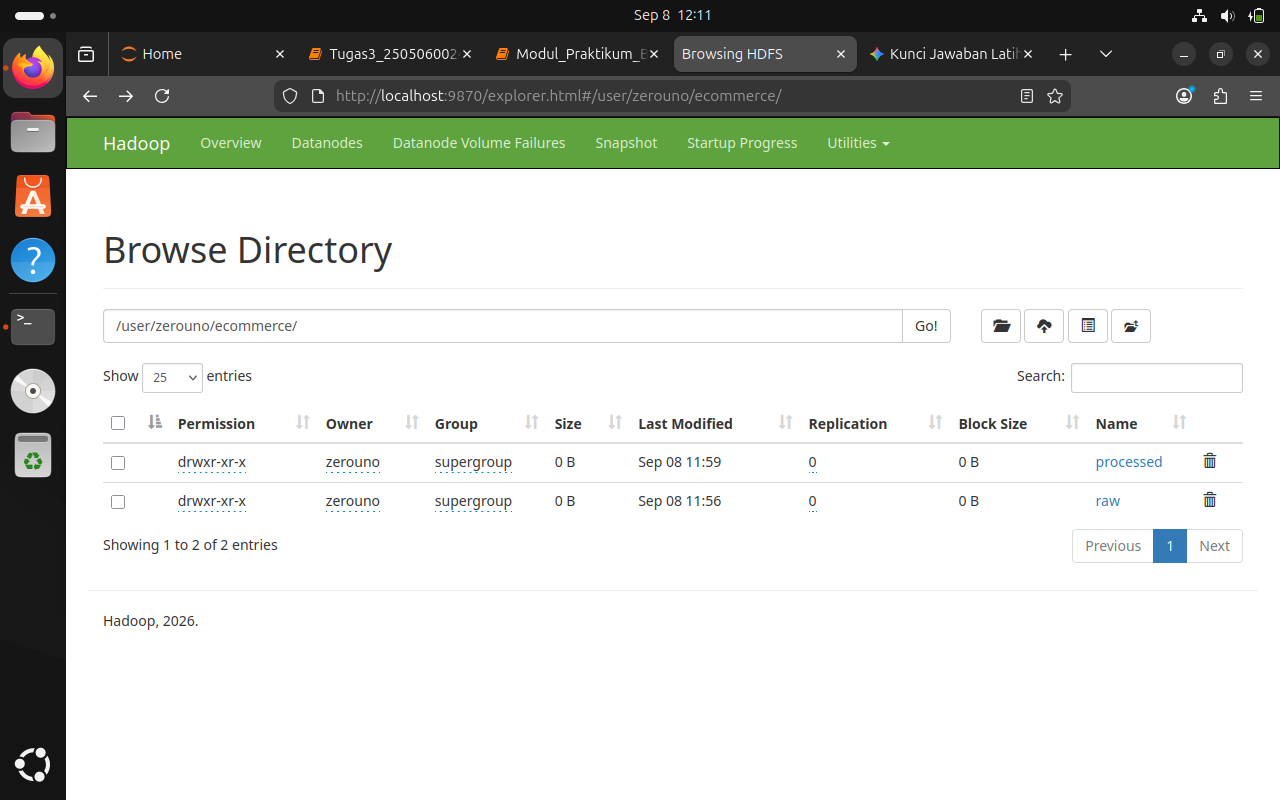
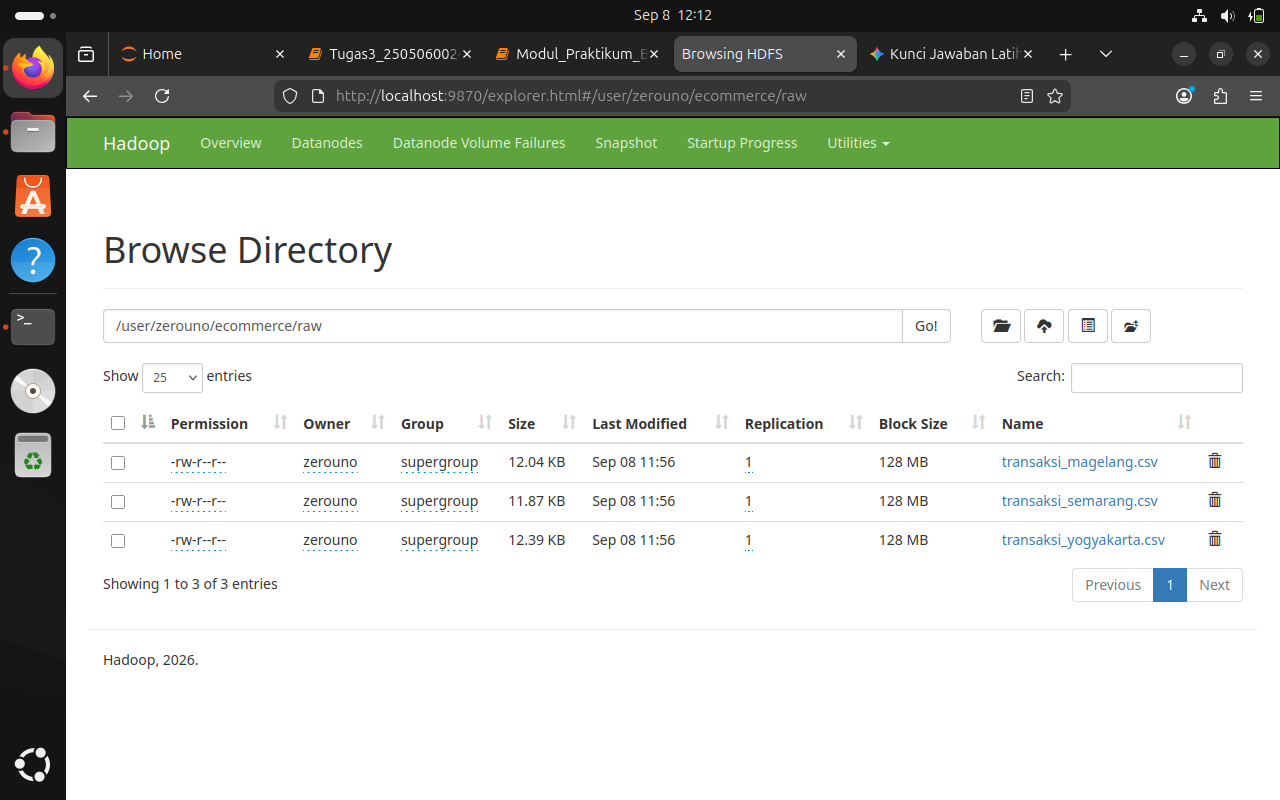
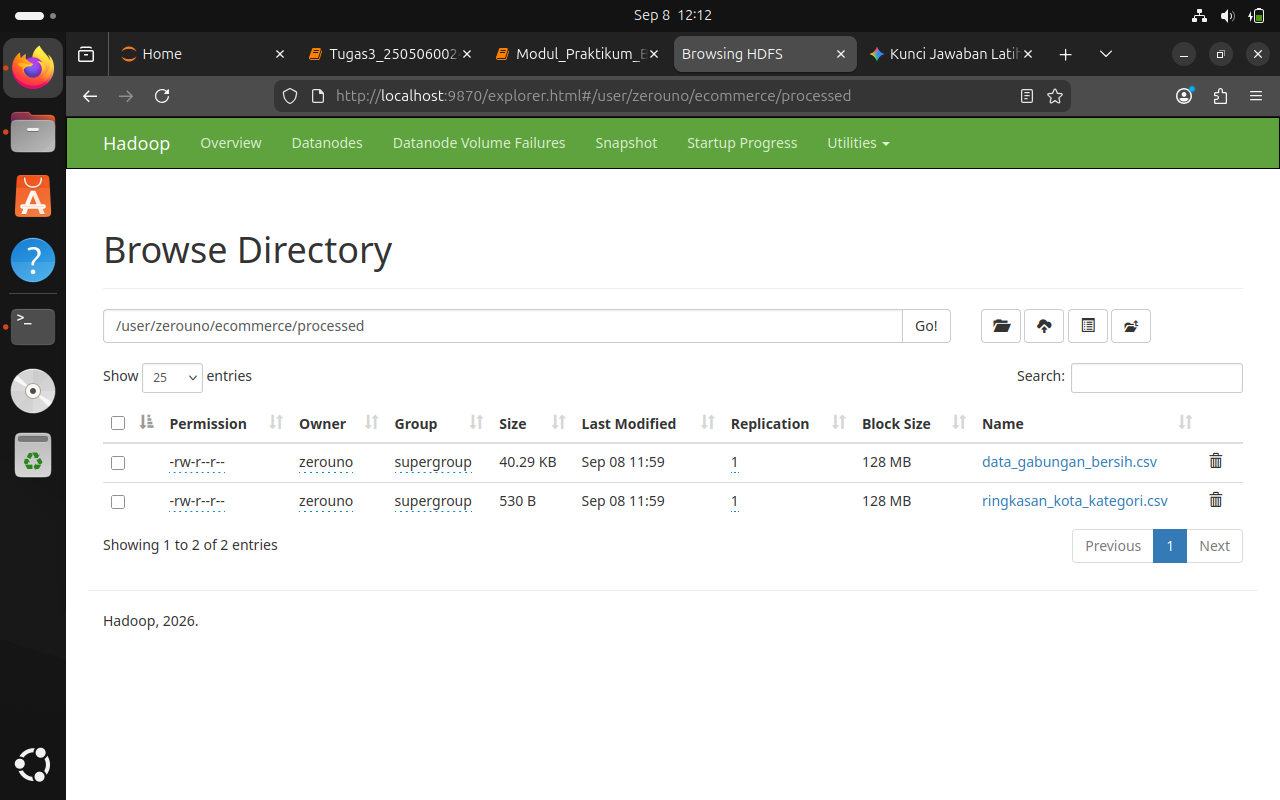

Refleksi

Memisahkan direktori data mentah (*raw*) dan data olahan (*processed*) di HDFS memberikan berbagai keuntungan signifikan dalam tata kelola data (*data governance*). Pertama, pemisahan ini menjaga integritas data awal (*data immutability*). Data mentah tetap murni dan tidak berisiko terhapus, terubah, atau tertimpa secara tidak sengaja saat proses analisis berlangsung. Jika terdapat kesalahan dalam logika pemrosesan atau algoritma pembersihan data di kemudian hari, kita selalu dapat kembali ke data mentah untuk melakukan pemrosesan ulang dari awal (*re-processing*).

Kedua, struktur direktori yang terorganisir memudahkan pengaturan hak akses (*access control*) dan keamanan sistem. Tim *data engineer* dapat diberikan hak akses penuh ke direktori data mentah, sedangkan tim *data analyst* atau *business intelligence* cukup diberikan akses ke direktori *processed* yang datanya sudah bersih dan siap dikonsumsi untuk laporan.

Ketiga, efisiensi alur kerja (*data pipeline*) menjadi jauh lebih optimal. Sistem analitik tidak perlu membuang waktu dan daya komputasi untuk membersihkan data berulang kali, karena data olahan bernilai tinggi sudah tersimpan dengan rapi di direktori terpisah. Hal ini sangat mendukung keteraturan arsitektur *data lake* yang profesional, aman, dan mudah diskalakan.